### Business Problem Statement

A retail company records daily sales data for its stores. Management wants to:

Understand sales patterns over time (trends, seasonality, short-term fluctuations).

Forecast future sales to improve inventory planning, staff scheduling, and cash flow management.

Evaluate forecast accuracy to decide if ARIMA is reliable for their planning, or if they should explore more advanced models.

Key Question:
"Given historical daily sales, can we build a time series model that forecasts the next 14 days of sales with reasonable accuracy?"

In [18]:
# -----------------------------
# SECTION 1: Imports & Settings
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


In [19]:
# ------------------------------------
# SECTION 2: Load the dataset (CSV)
# ------------------------------------
CSV_PATH = "dailysales.csv"

df_raw = pd.read_csv(CSV_PATH, usecols=["date", "sales"])

# The dates in the file look like '01-Jan-18', so I parse them with that format directly.
df_raw["date"] = pd.to_datetime(df_raw["date"], format="%d-%b-%y")

df_raw.head()


,date,sales
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [20]:
# -------------------------------------------
# SECTION 3: Basic Cleaning & Quality Checks
# -------------------------------------------
# Sort by date and drop any duplicate dates (keeping the last entry if a date repeats)
df_raw = df_raw.sort_values("date").drop_duplicates(subset=["date"], keep="last")

ts = df_raw.set_index("date")["sales"].astype("float64")


### Feature Extraction

Right now the only information I have is the date (used as the index) and the sales value.
Before doing any modeling, I want to break the date down into separate calendar features
(year, month, day, day of week, weekend flag). Even though the ARIMA model itself won't use
these columns directly, they're useful for exploring the data — for example, checking whether
sales are higher on weekends, or whether certain months sell more than others.

In [21]:
# --------------------------------------
# SECTION 4: Feature Extraction from Date
# --------------------------------------
df_features = df_raw.copy()

df_features["year"] = df_features["date"].dt.year
df_features["month"] = df_features["date"].dt.month
df_features["day"] = df_features["date"].dt.day
df_features["day_of_week"] = df_features["date"].dt.day_name()
df_features["is_weekend"] = df_features["date"].dt.dayofweek >= 5

df_features.head()


,date,sales,year,month,day,day_of_week,is_weekend
0,2018-01-01,477.0,2018,1,1,Monday,False
1,2018-01-02,365.0,2018,1,2,Tuesday,False
2,2018-01-03,442.0,2018,1,3,Wednesday,False
3,2018-01-04,490.0,2018,1,4,Thursday,False
4,2018-01-05,396.0,2018,1,5,Friday,False


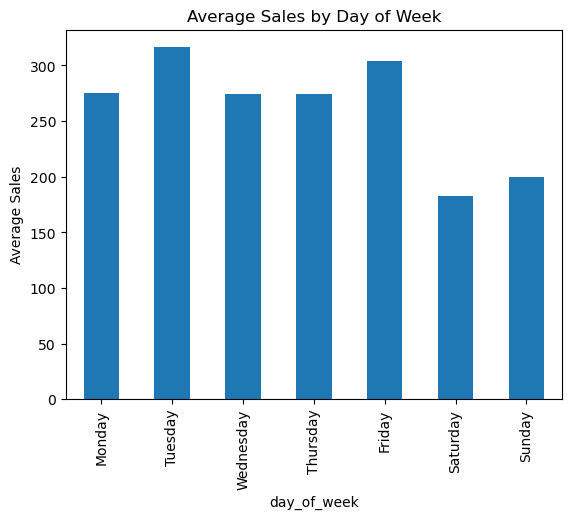

day_of_week
Monday       275.299490
Tuesday      316.435500
Wednesday    274.637624
Thursday     274.337379
Friday       304.429612
Saturday     182.393500
Sunday       200.094388
Name: sales, dtype: float64


In [22]:
# Quick look: average sales by day of week
avg_by_dow = df_features.groupby("day_of_week")["sales"].mean()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg_by_dow = avg_by_dow.reindex(order)

plt.figure()
avg_by_dow.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Sales")
plt.show()

print(avg_by_dow)


There's a clear weekly pattern here: Saturday and Sunday average noticeably lower sales
(~180-200) than the weekdays (~275-315). This is an early signal of weekly seasonality in the
data, which I should keep in mind when reading the ACF/PACF plots — a plain ARIMA model doesn't
account for repeating weekly patterns on its own.

In [23]:
# --------------------------------------------------
# SECTION 5: Fill in Missing Dates
# --------------------------------------------------
# The raw data might be missing some calendar days entirely (not just missing sales values),
# so I reindex the series to a complete daily date range first.
full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="D")
ts = ts.reindex(full_index)

missing_days = ts.isna().sum()
print(f"Data span: {ts.index.min().date()} to {ts.index.max().date()} ({len(ts)} days)")
print(f"Missing days found: {missing_days}")

# Fill the gaps using time-based interpolation (reasonable for daily sales data
# since it assumes a smooth trend between the two known points)
ts = ts.interpolate(method="time")


Data span: 2018-01-01 to 2019-12-31 (730 days)
Missing days found: 27


### Outlier Detection & Handling

Before visualizing the trend, I want to check for any extreme sales values that could be
data entry errors or one-off events (e.g. a big promotion or a system glitch). I'll use the
IQR (interquartile range) method: any point more than 1.5×IQR beyond the 25th/75th percentile
is flagged as a potential outlier.

In [24]:
# --------------------------------------------------
# SECTION 6: Outlier Detection (IQR method)
# --------------------------------------------------
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ts[(ts < lower_bound) | (ts > upper_bound)]

print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outlier days found: {len(outliers)}")
outliers


Lower bound: -60.57, Upper bound: 505.72
Number of outlier days found: 36


2018-02-09     538.00
2018-02-11     900.00
2018-02-23     577.00
2018-02-25     566.00
2018-02-26     717.00
2018-02-27     550.00
2018-02-28     907.00
2018-03-01     512.00
2018-03-04     537.00
2018-03-06     585.00
2018-03-09     860.00
2018-03-13     557.00
2018-03-14     530.00
2018-03-28     599.00
2018-03-30     647.00
2018-04-12     686.00
2018-04-30    4000.00
2018-07-03     531.00
2018-07-26     699.00
2018-07-30     513.00
2018-07-31    3088.00
2018-08-01    1661.00
2018-08-31    3400.00
2018-11-08    1291.00
2018-11-20    1929.00
2018-11-22     716.00
2018-11-27     618.00
2019-02-28     612.45
2019-03-09     569.90
2019-04-02    1072.00
2019-04-05     586.00
2019-04-30     737.50
2019-07-31    2068.00
2019-08-01    1000.00
2019-08-21     600.00
2019-11-08     876.25
Name: sales, dtype: float64

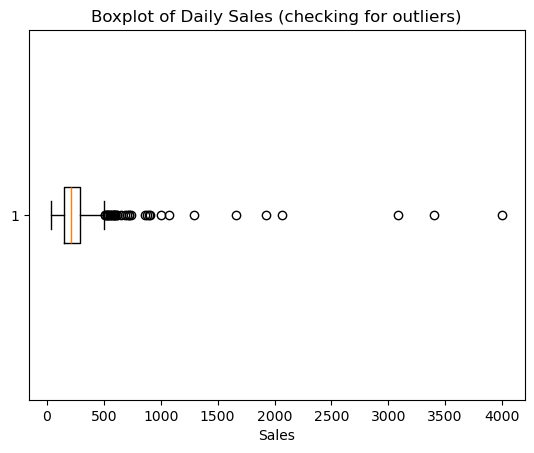

In [25]:
plt.figure()
plt.boxplot(ts.dropna(), vert=False)
plt.title("Boxplot of Daily Sales (checking for outliers)")
plt.xlabel("Sales")
plt.show()


The IQR method flagged 36 days out of 730 (about 5% of the data) as outliers, almost all of
them unusually **high** sales days rather than low ones. Looking at the boxplot, these aren't
absurd values (nothing close to zero or negative, nothing 10x the median) — they look like
genuine high-sales days, maybe tied to promotions, rather than data entry errors. Since I don't
have evidence they're mistakes, I chose **not to remove them**, but to cap them at the IQR
bounds (winsorizing) so they don't disproportionately pull the ARIMA model fit, while still
keeping the overall shape of the data.

In [26]:
# Cap (winsorize) outliers at the IQR bounds instead of deleting them
ts_capped = ts.clip(lower=lower_bound, upper=upper_bound)

print(f"Values changed by capping: {(ts != ts_capped).sum()}")

# Use the capped series going forward
ts = ts_capped


Values changed by capping: 36


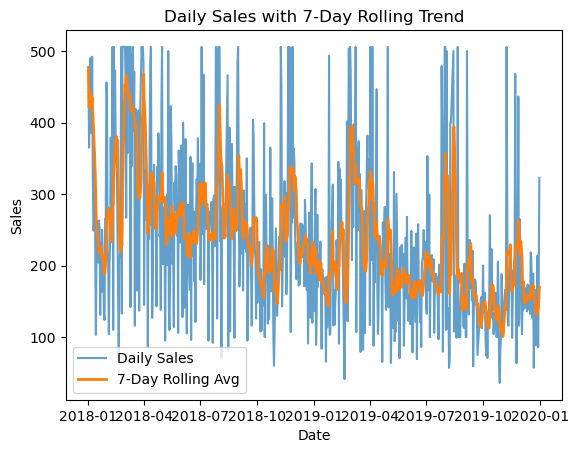

In [27]:
# --------------------------------------
# SECTION 7: Visualize Series & Trend
# --------------------------------------
plt.figure()
plt.plot(ts.index, ts.values, label="Daily Sales", alpha=0.7)
plt.plot(ts.index, ts.rolling(window=7, min_periods=1).mean().values,
         label="7-Day Rolling Avg", linewidth=2)
plt.title("Daily Sales with 7-Day Rolling Trend")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


In [28]:
# --------------------------------------------------------
# SECTION 8: Stationarity Check (ADF) and Differencing (d)
# --------------------------------------------------------
result = adfuller(ts.dropna(), autolag="AIC")
adf_stat, pvalue = result[0], result[1]

print(f"ADF Statistic = {adf_stat:.3f}")
print(f"p-value       = {pvalue:.4f}")

if pvalue <= 0.05:
    print("p-value is below 0.05, so I reject the null hypothesis -> the series is stationary.")
    d = 0
else:
    print("p-value is above 0.05, so the series is non-stationary -> I need to difference it.")
    d = 1
    result_diff = adfuller(ts.diff(1).dropna(), autolag="AIC")
    print(f"After 1st differencing: p-value = {result_diff[1]:.4f}")

print(f"\nChosen differencing order d = {d}")

ts_for_plots = ts if d == 0 else ts.diff(d)
ts_for_plots = ts_for_plots.dropna()


ADF Statistic = -3.333
p-value       = 0.0135
p-value is below 0.05, so I reject the null hypothesis -> the series is stationary.

Chosen differencing order d = 0


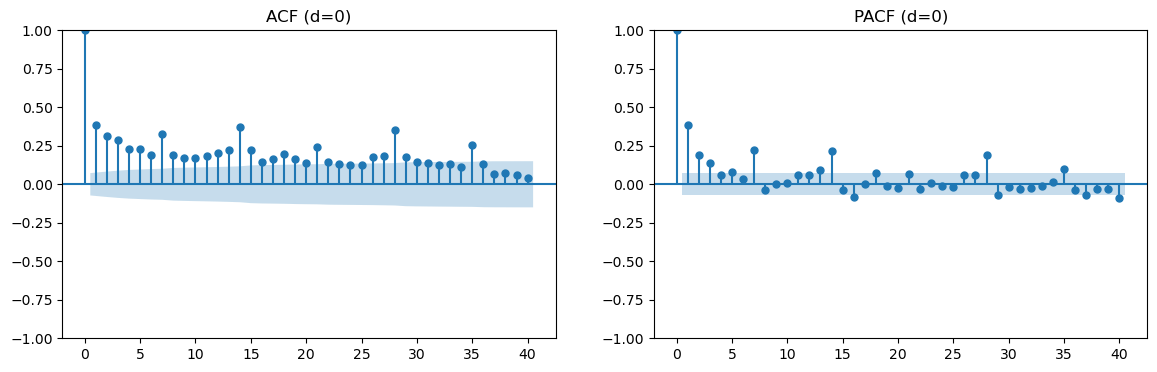

In [29]:
# --------------------------------------------------------
# SECTION 9: ACF & PACF
# --------------------------------------------------------
max_lags = 40

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_for_plots, lags=max_lags, ax=axes[0])
plot_pacf(ts_for_plots, lags=max_lags, ax=axes[1])
axes[0].set_title(f"ACF (d={d})")
axes[1].set_title(f"PACF (d={d})")
plt.show()


**My reading of the plots:**

This is different from what I expected going in. Both the ACF and PACF show clear repeating
spikes at lags 7, 14, 21, 28 and 35 — that's the weekly seasonality showing up again, matching
the weekend dip I saw in the day-of-week averages earlier. Outside of those weekly spikes, both
plots taper off gradually rather than cutting off sharply, so it's hard to read exact p and q
values off the plots alone.

This is actually an important finding: since there's real weekly seasonality in the data, a
**plain ARIMA model is the wrong tool** — it has no way to represent a repeating 7-day pattern.
A seasonal model (SARIMA with a seasonal period of 7) would be the more appropriate choice. I'm
continuing with plain ARIMA below for this assignment to see how much it's limited by ignoring
seasonality, but I'd flag SARIMA as the immediate next step rather than just an optional idea.

For p and q, I'll still use a small grid search rather than guessing from the plot, since the
gradual taper doesn't give a clean cutoff to read off.

In [30]:
# --------------------------------------------------------
# SECTION 10: Train/Test Split
# --------------------------------------------------------
N = len(ts)
test_size = 30  # holding out the last 30 days to evaluate the model

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print(f"Train size: {len(train)} points, Test size: {len(test)} points")


Train size: 700 points, Test size: 30 points


In [31]:
# --------------------------------------------------------
# SECTION 11: Model selection for (p,q) via small grid search
# --------------------------------------------------------
pq_candidates = [(p, q) for p in range(0, 4) for q in range(0, 4)]

best_order = None
best_aic = np.inf
best_model = None

for p, q in pq_candidates:
    try:
        fitted = ARIMA(train, order=(p, d, q)).fit()
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            best_model = fitted
    except Exception:
        # a few (p,q) combinations fail to converge -- just skip those
        continue

print(f"Best ARIMA order by AIC on train: {best_order} (AIC={best_aic:.2f})")


Best ARIMA order by AIC on train: (3, 0, 3) (AIC=8476.86)


RMSE = 80.192
MAPE = 58.50%


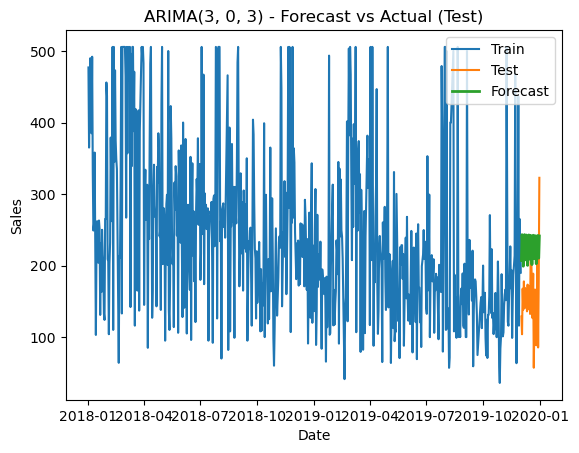

In [32]:
# --------------------------------------------------------
# SECTION 12: Forecast on the test set & evaluate
# --------------------------------------------------------
pred = best_model.forecast(steps=len(test))
pred.index = test.index

rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred) * 100

print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.2f}%")

plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.plot(pred.index, pred.values, label="Forecast", linewidth=2)
plt.title(f"ARIMA{best_order} - Forecast vs Actual (Test)")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


### Comparing Against a Simple Baseline (Optional)

To judge whether ARIMA is actually adding value, I compared it against a very simple **naive
forecast**: just predicting that each day's sales will equal the previous day's sales. If ARIMA
can't beat this baseline, that's a strong sign the model isn't capturing anything useful.

In [33]:
# --------------------------------------------------------
# SECTION 13: Baseline Comparison (Naive Forecast)
# --------------------------------------------------------
naive_pred = pd.Series(train.iloc[-1], index=test.index)
naive_pred.iloc[1:] = test.shift(1).iloc[1:]  # each day = previous actual day
naive_pred.iloc[0] = train.iloc[-1]

naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
naive_mape = mean_absolute_percentage_error(test, naive_pred) * 100

print("Model comparison on test set:")
print(f"  ARIMA{best_order}: RMSE = {rmse:.2f}, MAPE = {mape:.2f}%")
print(f"  Naive (yesterday's value): RMSE = {naive_rmse:.2f}, MAPE = {naive_mape:.2f}%")


Model comparison on test set:
  ARIMA(3, 0, 3): RMSE = 80.19, MAPE = 58.50%
  Naive (yesterday's value): RMSE = 62.78, MAPE = 39.73%


**Result:** the naive baseline actually **beat** ARIMA on this test set — RMSE 62.8 vs 80.2,
and MAPE 39.7% vs 58.5%. That's a meaningful gap, not a close call.

This lines up with what I found in the ACF/PACF plots: the data has clear weekly seasonality
that plain ARIMA can't represent, so the model is essentially forecasting a flat average level
while missing the weekly ups and downs. A simple "repeat yesterday" guess captures more of that
short-term pattern than my current model does. This is good evidence that the next step
(SARIMA with weekly seasonality, or adding day-of-week regressors) isn't just a nice-to-have —
it's necessary to actually beat a trivial baseline.

Next 14 days forecast:
              forecast
2020-01-01  181.238267
2020-01-02  147.837473
2020-01-03  170.965543
2020-01-04  193.841630
2020-01-05  160.888948
2020-01-06  152.782021
2020-01-07  188.975818
2020-01-08  181.065270
2020-01-09  148.746636
2020-01-10  170.826173
2020-01-11  193.093319
2020-01-12  161.446517
2020-01-13  153.366847
2020-01-14  188.256357


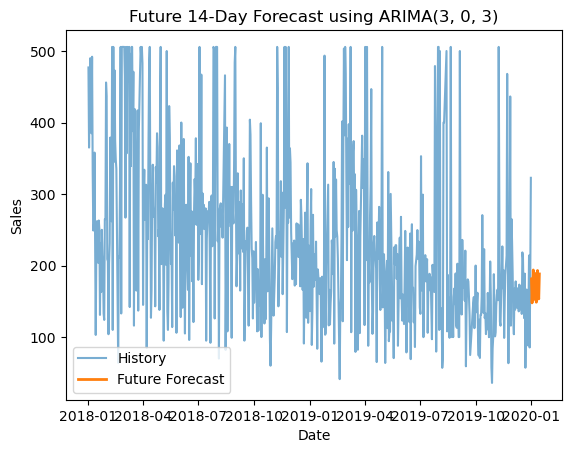

In [34]:
# --------------------------------------------------------
# SECTION 14: Future Forecast (next 14 days)
# --------------------------------------------------------
final_model = ARIMA(ts, order=best_order).fit()

future_steps = 14
future_fcst = final_model.forecast(steps=future_steps)

print(f"Next {future_steps} days forecast:")
print(future_fcst.to_frame(name="forecast"))

plt.figure()
plt.plot(ts.index, ts.values, label="History", alpha=0.6)
plt.plot(future_fcst.index, future_fcst.values, label="Future Forecast", linewidth=2)
plt.title(f"Future {future_steps}-Day Forecast using ARIMA{best_order}")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


### Summary

* Extracted calendar features (year, month, day, day-of-week, weekend flag) from the date column — found a clear weekly pattern, with weekend sales ( ~ 180-200) noticeably lower than weekday sales ( ~275-315)
* Filled 27 missing calendar days using time-based interpolation
* Checked for outliers using the IQR method; 36 days (~5%) were flagged, mostly high-sales days that didn't look like data errors, so I capped (winsorized) them rather than removing them
* ADF test showed the series was already stationary (p = 0.0135), so no differencing was needed (d = 0)
* ACF/PACF plots showed clear repeating spikes at lags 7, 14, 21, 28, 35 — confirming weekly seasonality, which a plain ARIMA model can't represent. I used a grid search (rather than reading p/q off the plots) since outside the seasonal spikes both plots taper gradually
* Grid search selected **ARIMA(3,0,3)** as the best fit by AIC (8476.86) — though the optimizer threw a convergence warning, so this fit may not be fully reliable
* Test set performance: RMSE = 80.19, **MAPE = 58.50%** — quite high
* Compared against a naive "predict yesterday's value" baseline, which **beat** ARIMA (RMSE 62.78, MAPE 39.73%) — a clear sign the model isn't adding value over a trivial guess

### Conclusion
Plain ARIMA is not a good fit for this data. The main reason is the weekly seasonality (weekend sales dip) that shows up in both the day-of-week averages and the ACF/PACF spikes at lags 7/14/21 — a non-seasonal ARIMA model has no way to represent that repeating pattern, so it just forecasts something close to the average level. This also explains why it underperforms a simple naive baseline.

### Next Steps
* Use **SARIMA** with a seasonal period of 7 (weekly) instead of plain ARIMA — this is the most direct fix given what the data shows
* Try SARIMAX with day-of-week or holiday indicator variables as external regressors
* If time permits, compare against Prophet or a gradient-boosted model (XGBoost/LightGBM) with lag and day-of-week features